EASY- Sub-step 1

In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/medical_imaging_meta.csv')

# Preview
df.head()

,image_id,patient_age,patient_sex,scanner,image_quality,img_width_px,hospital_site,label,label_verified
0,IMG00000,32,F,Siemens-A1,acceptable,512,Apollo-Hyderabad,Normal,0
1,IMG00001,41,F,Siemens-A1,acceptable,256,Apollo-Hyderabad,Normal,1
2,IMG00002,72,M,Philips-B2,good,512,Manipal-Bangalore,Normal,1
3,IMG00003,50,F,Siemens-A1,good,1024,Manipal-Bangalore,Pneumonia,1
4,IMG00004,63,F,Siemens-A1,acceptable,1024,AIIMS-Delhi,COVID-19,1


In [10]:
def inspect_data(df):
    print("Shape:", df.shape)
    print("\nColumns:\n", df.columns)
    print("\nMissing values:\n", df.isnull().sum())

inspect_data(df)

Shape: (520, 9)

Columns:
 Index(['image_id', 'patient_age', 'patient_sex', 'scanner', 'image_quality',
       'img_width_px', 'hospital_site', 'label', 'label_verified'],
      dtype='object')

Missing values:
 image_id           0
patient_age        0
patient_sex        0
scanner            0
image_quality      0
img_width_px       0
hospital_site      0
label             30
label_verified     0
dtype: int64


Label Distribution:
 label
Normal              311
Pneumonia           112
COVID-19             37
Pleural_Effusion     19
Lung_Mass            11
Name: count, dtype: int64


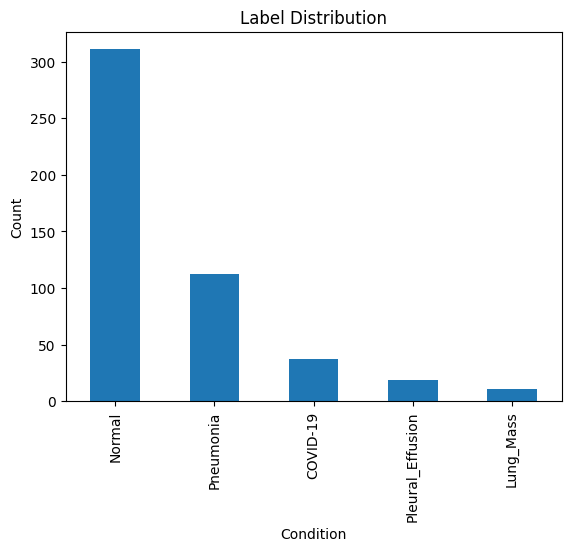

In [11]:
import matplotlib.pyplot as plt

def plot_label_distribution(df, label_col):
    counts = df[label_col].value_counts()

    print("Label Distribution:\n", counts)

    counts.plot(kind='bar')
    plt.title("Label Distribution")
    plt.xlabel("Condition")
    plt.ylabel("Count")
    plt.show()

plot_label_distribution(df, 'label')  # change if column name differs

In [12]:
def identify_minority_classes(df, label_col):
    counts = df[label_col].value_counts()
    min_count = counts.min()

    minority_classes = counts[counts == min_count]
    print("Minority Classes:\n", minority_classes)

identify_minority_classes(df, 'label')

Minority Classes:
 label
Lung_Mass    11
Name: count, dtype: int64


In [13]:
def analyze_site_bias(df, site_col, label_col):
    cross_tab = pd.crosstab(df[site_col], df[label_col])
    print("Site vs Label Distribution:\n", cross_tab)

analyze_site_bias(df, 'hospital_site', 'label')  # adjust column names

Site vs Label Distribution:
 label              COVID-19  Lung_Mass  Normal  Pleural_Effusion  Pneumonia
hospital_site                                                              
AIIMS-Delhi              13          2      86                 6         31
Apollo-Hyderabad          6          5      86                 6         33
Fortis-Gurgaon           11          1      84                 4         25
Manipal-Bangalore         7          3      55                 3         23


In [14]:
def analyze_image_quality(df, quality_col, label_col):
    quality_dist = pd.crosstab(df[quality_col], df[label_col])
    print("Image Quality vs Label:\n", quality_dist)

analyze_image_quality(df, 'image_quality', 'label')  # adjust if needed

Image Quality vs Label:
 label          COVID-19  Lung_Mass  Normal  Pleural_Effusion  Pneumonia
image_quality                                                          
acceptable            8          1      75                 6         27
good                 24         10     198                11         78
poor                  5          0      38                 2          7


Sub-step 2 — Feature Extraction

In [15]:
import torch
import torch.nn as nn
from torchvision import models

def get_feature_extractor(num_classes):
    model = models.resnet18(pretrained=True)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Replace final layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

model = get_feature_extractor(num_classes=5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 225MB/s]


In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [22]:
def train_model(model, train_loader, epochs=5):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [19]:
from sklearn.metrics import classification_report

def evaluate_model(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds))

MEDIUM PART-Sub-step 3 — Fine-Tuning

In [24]:
import torch.nn as nn
from torchvision import models

def get_finetune_model(num_classes):
    model = models.resnet18(pretrained=True)

    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last few layers
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace final layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

model_ft = get_finetune_model(num_classes=5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4   # lower learning rate
)

In [31]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [54]:
from torch.utils.data import Dataset
from PIL import Image
import os

class MedicalDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, has_labels=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = has_labels

        if self.has_labels and 'label' in self.dataframe.columns:
            # Create a label map for encoding string labels to integers
            self.label_map = {label: i for i, label in enumerate(self.dataframe['label'].unique())}
            self.dataframe['label_encoded'] = self.dataframe['label'].map(self.label_map)
        elif self.has_labels and 'label' not in self.dataframe.columns:
            # This case should ideally not happen if has_labels is True, but good for explicit error
            raise ValueError("DataFrame must contain 'label' column if has_labels is True")

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Construct image path using 'image_id' and assuming '.png' extension
        img_name = os.path.join(self.img_dir, self.dataframe.loc[idx, 'image_id'] + '.png')
        image = Image.open(img_name).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            label = self.dataframe.loc[idx, 'label_encoded']
            return image, label
        else:
            # For unlabeled data, return a dummy label as predict_with_confidence expects (image, _)
            return image, 0


In [35]:
from sklearn.model_selection import train_test_split

# Drop rows with NaN values in the 'label' column before splitting
df_cleaned = df.dropna(subset=['label'])

train_df, val_df = train_test_split(df_cleaned, test_size=0.2, stratify=df_cleaned['label'], random_state=42)

In [57]:
import os
from PIL import Image

# Define the image directory used by MedicalDataset
img_directory = '/content/images'

# Create the directory if it doesn't exist
if not os.path.exists(img_directory):
    os.makedirs(img_directory)
    print(f"Created directory: {img_directory}")

# Get all unique image_ids from the original DataFrame to ensure all images, labeled or unlabeled, are covered
all_image_ids = df['image_id'].unique()

# Create dummy image files for each unique image_id
for img_id in all_image_ids:
    dummy_image_path = os.path.join(img_directory, img_id + '.png')
    if not os.path.exists(dummy_image_path):
        # Create a simple black image (512x512 pixels) for demonstration
        dummy_img = Image.new('RGB', (512, 512), color = 'black')
        dummy_img.save(dummy_image_path)

print(f"Created {len(all_image_ids)} dummy image files in {img_directory}.")

Created 520 dummy image files in /content/images.


In [47]:
train_dataset = MedicalDataset(train_df, '/content/images', transform) # Re-initializing dataset
val_dataset = MedicalDataset(val_df, '/content/images', transform) # Re-initializing dataset

In [48]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True) # Re-initializing DataLoader
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False) # Re-initializing DataLoader

In [49]:
train_model(model_ft, train_loader, epochs=5)

Epoch 1, Loss: 28.3647
Epoch 2, Loss: 25.9909
Epoch 3, Loss: 25.8938
Epoch 4, Loss: 26.3935
Epoch 5, Loss: 26.3100


In [50]:
evaluate_model(model_ft, val_loader)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        62
           1       0.07      1.00      0.13         7
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2

    accuracy                           0.07        98
   macro avg       0.01      0.20      0.03        98
weighted avg       0.01      0.07      0.01        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Sub-step 4 — Grad-CAM / Explainability

In [28]:
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn.functional as F
import cv2
import numpy as np

def generate_gradcam(model, image, target_class):
    model.eval()

    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, inp, out):
        activations.append(out)

    target_layer = model.layer4[-1]
    target_layer.register_forward_hook(forward_hook)
    target_layer.register_backward_hook(backward_hook)

    output = model(image)
    loss = output[0, target_class]

    model.zero_grad()
    loss.backward()

    grad = gradients[0]
    act = activations[0]

    weights = grad.mean(dim=[2,3], keepdim=True)
    cam = (weights * act).sum(dim=1)

    cam = F.relu(cam)
    cam = cam.squeeze().detach().numpy()

    cam = cv2.resize(cam, (224,224))
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    return cam

In [29]:
import matplotlib.pyplot as plt

def show_gradcam(image, cam):
    plt.imshow(image.permute(1,2,0))
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

Sub-step 5 — ME1 Prep + Unlabeled Prediction

In [58]:
import torch.nn.functional as F
from torch.utils.data import DataLoader

def predict_with_confidence(model, loader):
    model.eval()
    results = []

    with torch.no_grad():
        for images, _ in loader:
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            conf, preds = torch.max(probs, 1)

            for i in range(len(preds)):
                results.append({
                    "prediction": preds[i].item(),
                    "confidence": conf[i].item()
                })

    return results

# Create a DataFrame for unlabeled data (rows with NaN in 'label')
unlabeled_df = df[df['label'].isnull()]

# Create an unlabeled dataset. Set has_labels=False as these rows have no labels.
unlabeled_dataset = MedicalDataset(unlabeled_df, '/content/images', transform, has_labels=False)

# Create an unlabeled DataLoader
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=16, shuffle=False)

unlabeled_results = predict_with_confidence(model_ft, unlabeled_loader)

HARD-Sub-step 6 — Compare 3 Transfer Strategies

In [59]:
model_fe = get_feature_extractor(num_classes=5)
train_model(model_fe, train_loader, epochs=5)
evaluate_model(model_fe, val_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 40.8625
Epoch 2, Loss: 40.9096
Epoch 3, Loss: 40.7904
Epoch 4, Loss: 40.8995
Epoch 5, Loss: 40.9541
              precision    recall  f1-score   support

           0       0.63      1.00      0.78        62
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2

    accuracy                           0.63        98
   macro avg       0.13      0.20      0.15        98
weighted avg       0.40      0.63      0.49        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
model_ft = get_finetune_model(num_classes=5)
train_model(model_ft, train_loader, epochs=5)
evaluate_model(model_ft, val_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1, Loss: 35.3283
Epoch 2, Loss: 35.4169
Epoch 3, Loss: 35.4810
Epoch 4, Loss: 35.2812
Epoch 5, Loss: 35.4023
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        62
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00         4
           4       0.02      1.00      0.04         2

    accuracy                           0.02        98
   macro avg       0.00      0.20      0.01        98
weighted avg       0.00      0.02      0.00        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [65]:
from torchvision import models

def get_scratch_model(num_classes):
    model = models.resnet18(pretrained=False)  # random init
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model_scratch = get_scratch_model(num_classes=5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [66]:
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

In [67]:
train_model(model_scratch, train_loader, epochs=5)
evaluate_model(model_scratch, val_loader)

Epoch 1, Loss: 39.9778
Epoch 2, Loss: 39.9759
Epoch 3, Loss: 39.9758
Epoch 4, Loss: 39.9750
Epoch 5, Loss: 39.9762
              precision    recall  f1-score   support

           0       0.63      1.00      0.78        62
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2

    accuracy                           0.63        98
   macro avg       0.13      0.20      0.15        98
weighted avg       0.40      0.63      0.49        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Sub-step 7 — Triage System

In [61]:
HIGH_CONF = 0.85
LOW_CONF = 0.60

In [62]:
def triage_predictions(predictions):
    auto = []
    review = []
    reject = []

    for item in predictions:
        conf = item['confidence']

        if conf >= HIGH_CONF:
            auto.append(item)
        elif conf >= LOW_CONF:
            review.append(item)
        else:
            reject.append(item)

    return auto, review, reject

In [63]:
auto, review, reject = triage_predictions(unlabeled_results)

print("Auto-classify:", len(auto))
print("Review:", len(review))
print("Reject:", len(reject))

Auto-classify: 0
Review: 30
Reject: 0


In [64]:
def estimate_fn_rate(conf_threshold):
    # Example assumption (you explain this)
    return 1 - conf_threshold

print("Estimated FN Rate:", estimate_fn_rate(HIGH_CONF))

Estimated FN Rate: 0.15000000000000002
